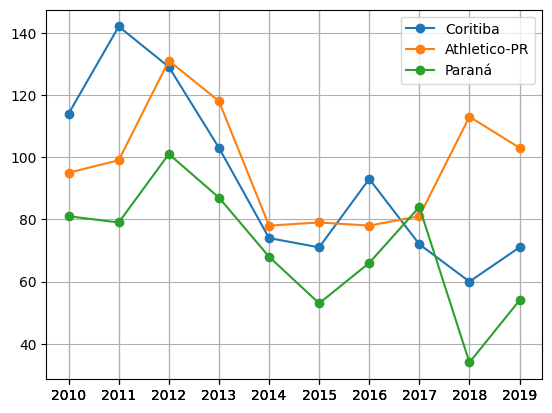

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

gols = pd.read_csv('CSVs/gols_pr.csv')

cwb = gols[gols['clube'] == 'coritiba']
atl = gols[gols['clube'] == 'athletico-pr']
par = gols[gols['clube'] == 'parana']

plt.plot(cwb.ano,cwb.gols_pro, marker='o',label='Coritiba')
plt.plot(atl.ano,atl.gols_pro, marker='o',label='Athletico-PR')
plt.plot(par.ano,par.gols_pro, marker='o',label='Paraná')
plt.xticks(gols['ano'])
plt.grid('compact')
plt.legend()
plt.show()

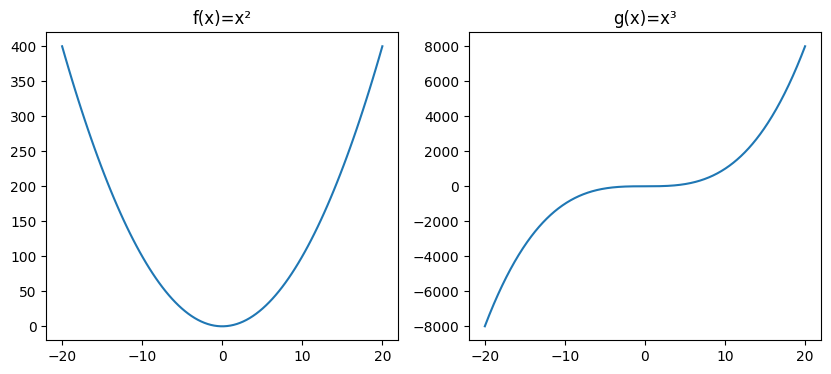

In [144]:
import numpy as np

x1 = np.linspace(-20,20,100)
y1 = x1**2

x2 = np.linspace(-20,20,1000)
y2 = x2**3

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(x1,y1)
axs[0].set_title('f(x)=x²')

axs[1].plot(x2,y2)
axs[1].set_title('g(x)=x³')

plt.show()

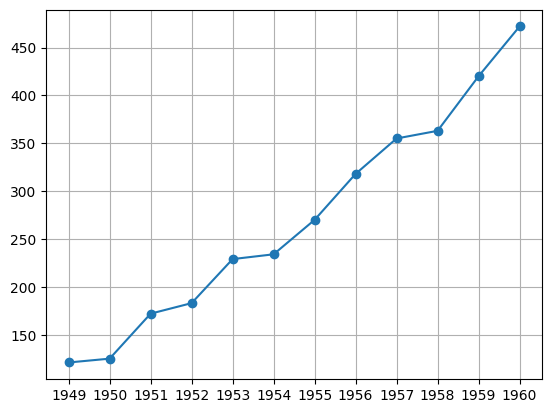

In [110]:
df = pd.read_csv('CSVs/flights.csv')
df = df[df['month'] == 'May']
df = df.groupby('year')['passengers'].sum().to_frame('passengers')
plt.grid('compact')
plt.xticks(df.index)
plt.plot(df,marker='o')
plt.show()


C:\Users\disrct\AppData\Local\Temp\ipykernel_11896\64654202.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['Duration'] = df2['duration'].str[:-3].astype(int)


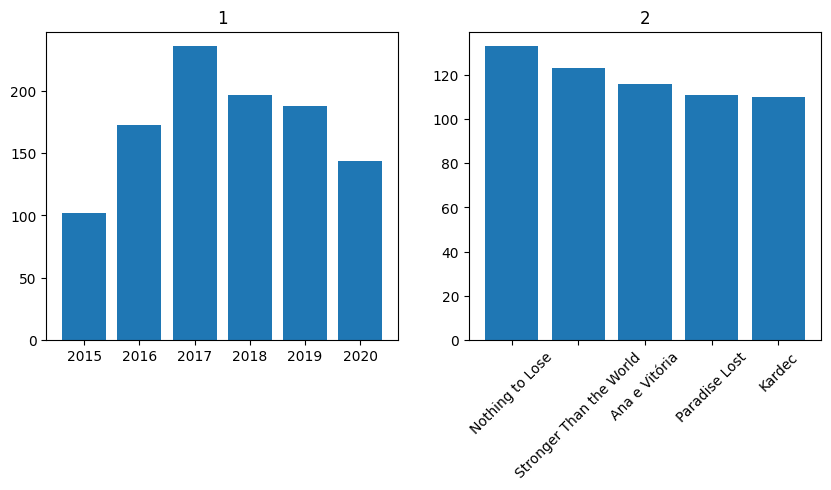

In [239]:
df = pd.read_csv('CSVs/netflix_titles.csv').dropna()

#primeiro
df1 = df[(df['release_year'] >= 2015) &
        (df['release_year'] <= 2020) &
        (df['country'] == 'United States')]

df1 = df1.groupby('release_year')['release_year'].count()

x1 = df1.index
y1 = df1

#segundo
df2 = df[(df['type'] == 'Movie') &
         (df['country'] == 'Brazil')]

df2['Duration'] = df2['duration'].str[:-3].astype(int)
df2 = df2.sort_values(by='Duration',ascending=False).head()

x2 = df2.title
y2 = df2.Duration

#junção

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].bar(x1,y1)
axs[0].set_title("1")
axs[1].bar(x2,y2)
axs[1].set_title("2")
axs[1].tick_params(axis='x', rotation=45)


<BarContainer object of 81 artists>

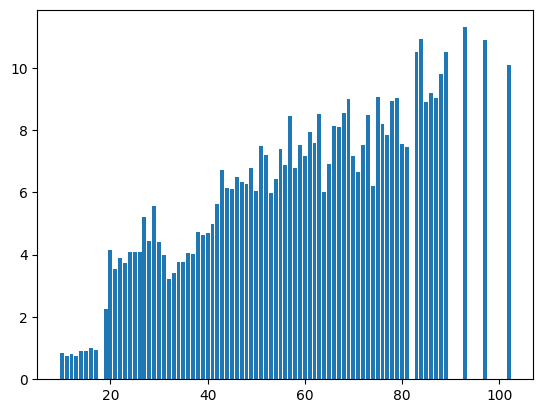

In [256]:
df = pd.read_csv('CSVs/cat_breeds_clean.csv',sep=';')
df = df.groupby('Body_length')['Weight'].mean()
plt.bar(df.index,df)

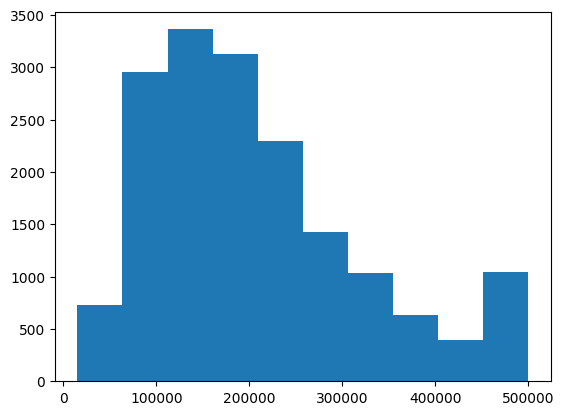

In [ ]:
df = pd.read_csv('CSVs/california_housing_train.csv')
plt.hist(df['median_house_value'])

plt.show()

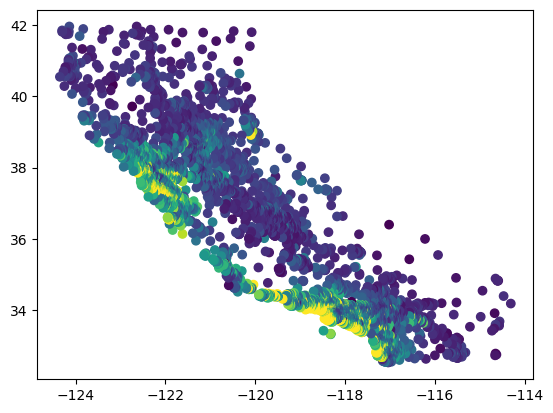

In [56]:
df = pd.read_csv('CSVs/california_housing_train.csv')

plt.scatter(df['longitude'], df['latitude'], c=df['median_house_value'])

plt.show()

In [5]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15,5612,1283,1015,472,1.4936,66900
1,-114.47,34.40,19,7650,1901,1129,463,1.8200,80100
2,-114.56,33.69,17,720,174,333,117,1.6509,85700
3,-114.57,33.64,14,1501,337,515,226,3.1917,73400
4,-114.57,33.57,20,1454,326,624,262,1.9250,65500


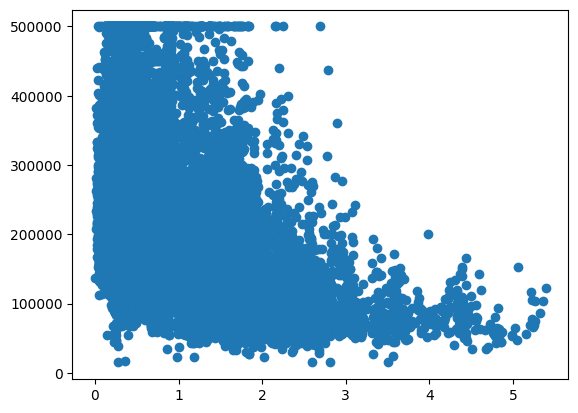

In [ ]:
import numpy as np

df = pd.read_csv('CSVs/california_housing_train.csv')

def minimo(linha):
    if linha['Distance to LA'] < linha['Distance to SF']:
        return linha['Distance to LA']
    else:
        return linha['Distance to SF']

df['Distance to LA'] = np.sqrt(((df.latitude - 34)**2) + ((df.longitude + 118)**2))
df['Distance to SF'] = np.sqrt(((df.latitude - 37)**2) + ((df.longitude + 122)**2))
df['min'] = df.apply(minimo,axis=1)

plt.scatter(df['min'],df['median_house_value'])
plt.show()

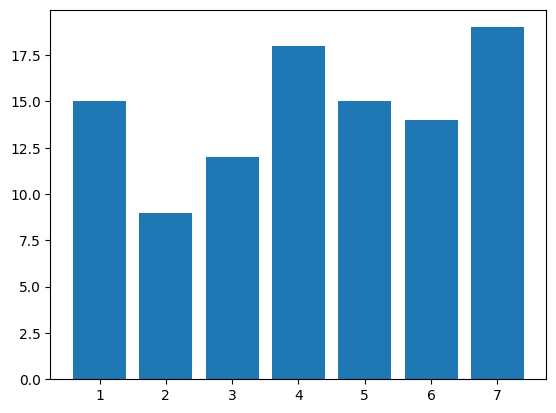

In [ ]:
df = pd.read_csv('CSVs/he.csv')
df = df.groupby('MachineId')['Id'].count()

plt.bar(df.index,df)
plt.show()

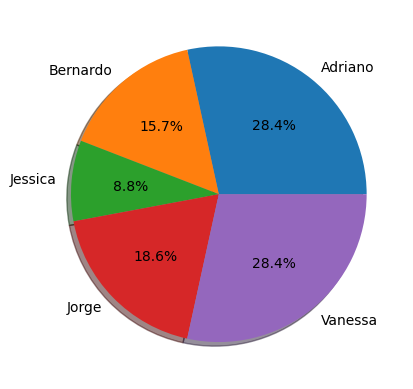

In [143]:
df = pd.read_csv('CSVs/he.csv')

df = df.groupby('responsible')['responsible'].count()

plt.pie(df,labels=df.index, shadow=True, autopct="%1.1f%%")
plt.show()

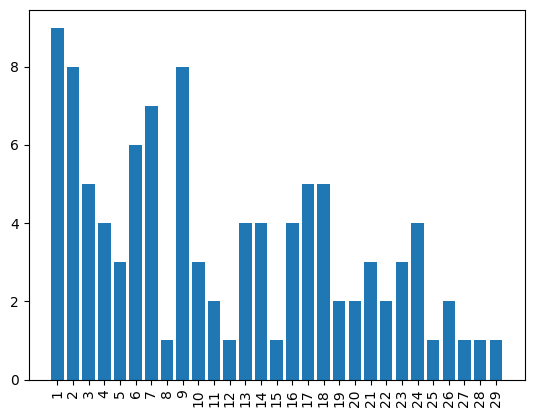

In [205]:
df = pd.read_csv('CSVs/he.csv')

def day(linha):
    
    if linha['start_date'][-2:  ].isnumeric():
        return linha['start_date'][-2:]
    else:
        return linha['start_date'][-1:]

df['day'] = df.apply(day,axis=1)

df = df.groupby('day')['day'].count()

df.index = df.index.astype(int)
df = df.sort_index()

plt.bar(df.index,df)
plt.xticks(df.index.unique(),rotation = 90)
plt.show()

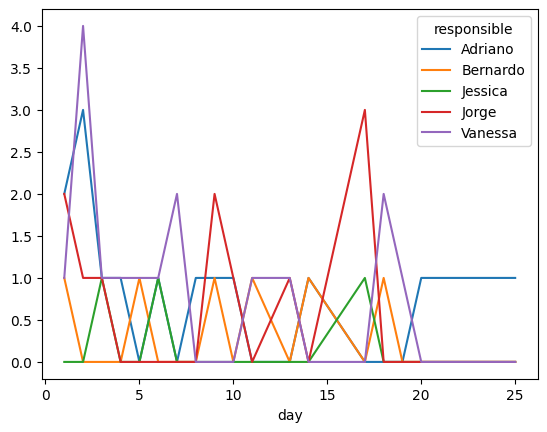

In [202]:
import numpy as np

df = pd.read_csv('CSVs/he.csv')

def day(linha):
    
    if linha['start_date'][-2:].isnumeric():
        return linha['start_date'][-2:]
    else:
        return linha['start_date'][-1:]

df['day'] = df.apply(day,axis=1)

df = df[df['is_corrective'] == 1]

df = df.groupby(['day','responsible'])['day'].count().unstack(fill_value=0)

df.index = df.index.astype(int)
df = df.sort_index()

df.plot()
plt.xticks()
plt.show()

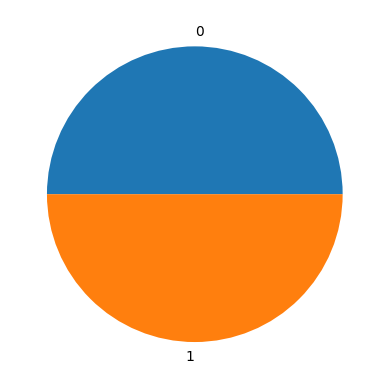

In [ ]:
df = pd.read_csv('CSVs/he.csv')

df = df.groupby('is_corrective')['is_corrective'].count()

plt.pie(df, labels=df.index)

plt.show()

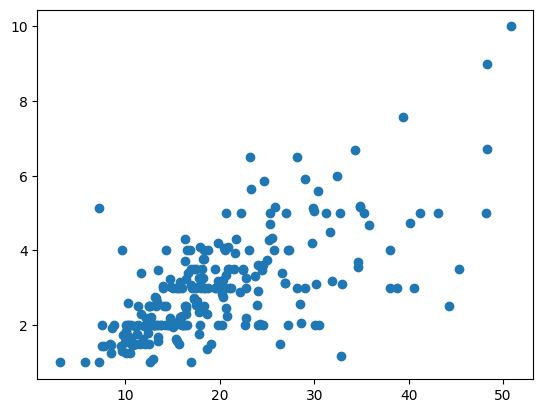

In [212]:
df = pd.read_csv('CSVs/tips.csv',sep=';')

plt.scatter(df.total_bill,df.tip)
plt.show()